In [2]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

df = pd.read_csv(r"E:\OptiCore_AI\data\processed\merged_energy_weather.csv")

# Remove unwanted columns
df = df.drop(columns=[
'time',
'weather_main',
'weather_description',
'weather_icon',
'hour_y',
'day_y',
'month_y',
'weekday_y',
'is_weekend_y',
'city_name',
'generation hydro pumped storage aggregated',
'forecast wind offshore eday ahead',
'total load forecast'
])

# Remove rows where target is NaN
df = df.dropna(subset=['total load actual'])

# Separate X and y
y = df['total load actual']
X = df.drop(columns=['total load actual'])

# Remove remaining NaN from X
X = X.dropna()

# Align y with X
y = y.loc[X.index]

print("X shape:", X.shape)
print("y shape:", y.shape)

# Time series split
split = int(len(X) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

lr_mae = mean_absolute_error(y_test, y_pred)
lr_r2 = r2_score(y_test, y_pred)

print("Linear Regression MAE:", lr_mae)
print("Linear Regression R2:", lr_r2)

X shape: (35971, 44)
y shape: (35971,)
Linear Regression MAE: 750.0022261098117
Linear Regression R2: 0.9560712698462309


In [3]:
# Random Forest regression model training and evaluation

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest MAE:", rf_mae)
print("Random Forest R2:", rf_r2)

Random Forest MAE: 366.7310357786161
Random Forest R2: 0.9849158963667916


In [4]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2 = r2_score(y_test, xgb_pred)

print("XGBoost MAE:", xgb_mae)
print("XGBoost R2:", xgb_r2)

XGBoost MAE: 350.0169535050382
XGBoost R2: 0.9868376899255792


In [5]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    layers.Dense(64, activation="relu"),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mae",
    metrics=["mae"]
)

model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

nn_pred = model.predict(X_test)



nn_mae = mean_absolute_error(y_test, nn_pred)
nn_r2 = r2_score(y_test, nn_pred)

print("Neural Network MAE:", nn_mae)
print("Neural Network R2:", nn_r2)

e:\OptiCore_AI\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1211.3453 - mae: 1211.3453 - val_loss: 874.4894 - val_mae: 874.4894
Epoch 2/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 806.1552 - mae: 806.1552 - val_loss: 762.4034 - val_mae: 762.4034
Epoch 3/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 760.0673 - mae: 760.0673 - val_loss: 736.0879 - val_mae: 736.0879
Epoch 4/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 731.4099 - mae: 731.4099 - val_loss: 708.2551 - val_mae: 708.2551
Epoch 5/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 705.2847 - mae: 705.2847 - val_loss: 718.3317 - val_mae: 718.3317
Epoch 6/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 688.9384 - mae: 688.9384 - val_loss: 685.6995 - val_mae: 685.6995
Epoch 7/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 674.5441 - mae: 674.5441 - val_loss: 682.4992 - val_mae: 682.4992
Epoch 8/20
720/720 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 657.8201 - mae: 657.8201 - val_loss: 916.1794 - val_mae:

In [6]:
# reshape for lstm model training (samples , timesteps , features)
X_train_lstm = X_train.values.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.values.reshape((X_test.shape[0], 1, X_test.shape[1]))

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

lstm_model = Sequential()

lstm_model.add(
    LSTM(
        64,
        activation="relu",
        input_shape=(X_train_lstm.shape[1], X_train_lstm.shape[2])
    )
)

lstm_model.add(Dense(1))

lstm_model.compile(
    optimizer="adam",
    loss="mae"
)

lstm_model.fit(
    X_train_lstm,
    y_train,
    epochs=10,
    batch_size=32
)

lstm_pred = lstm_model.predict(X_test_lstm)

lstm_mae = mean_absolute_error(y_test, lstm_pred)
lstm_r2 = r2_score(y_test, lstm_pred)

print("LSTM MAE:", lstm_mae)
print("LSTM R2:", lstm_r2)

Epoch 1/10


e:\OptiCore_AI\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2076.5066
Epoch 2/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 828.8134
Epoch 3/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 815.5558
Epoch 4/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 805.8871
Epoch 5/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 805.7127
Epoch 6/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 798.5530
Epoch 7/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 794.9064
Epoch 8/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 797.9761
Epoch 9/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 788.6564
Epoch 10/10
900/900 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 787.9515
225/225 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
LSTM MAE: 761.6906646325573
LSTM R2: 0.9537043064270403


In [8]:
results = pd.DataFrame({
"Model":[
"Linear Regression",
"Random Forest",
"XGBoost",
"Neural Network",
"LSTM"
],
"MAE":[
lr_mae,
rf_mae,
xgb_mae,
nn_mae,
lstm_mae
],
"R2":[
lr_r2,
rf_r2,
xgb_r2,
nn_r2,
lstm_r2
]
})

print(results)

               Model         MAE        R2
0  Linear Regression  750.002226  0.956071
1      Random Forest  366.731036  0.984916
2            XGBoost  350.016954  0.986838
3     Neural Network  638.239552  0.964606
4               LSTM  761.690665  0.953704


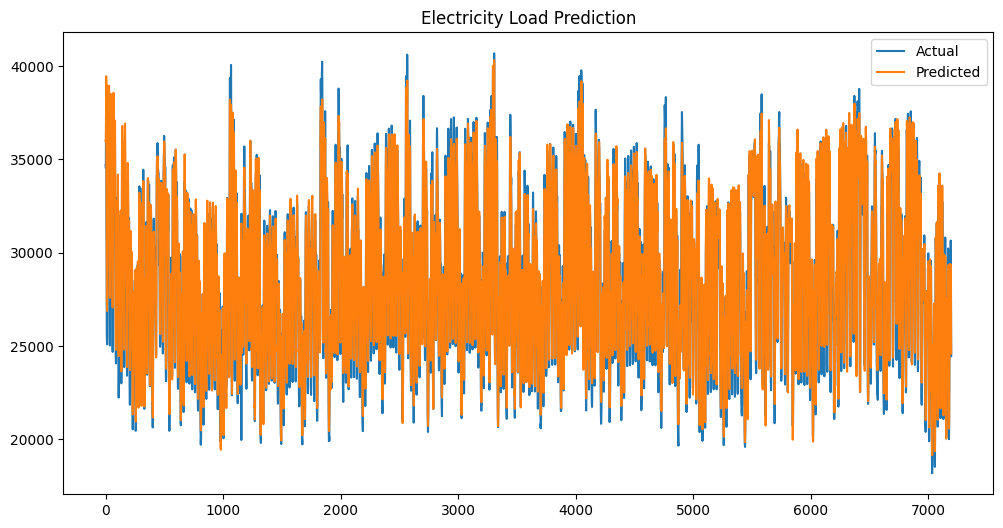

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")

plt.legend()
plt.title("Electricity Load Prediction")

plt.show()

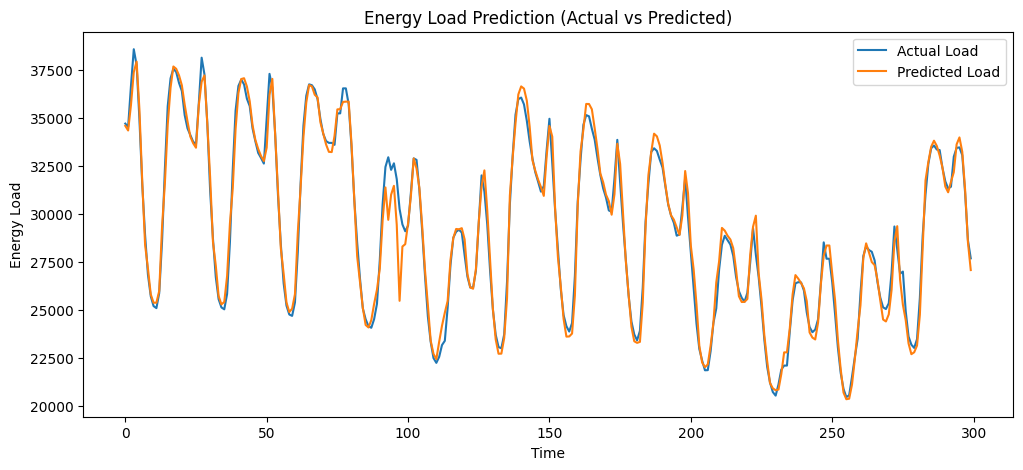

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.values[:300], label="Actual Load")
plt.plot(xgb_pred[:300], label="Predicted Load")

plt.legend()
plt.title("Energy Load Prediction (Actual vs Predicted)")
plt.xlabel("Time")
plt.ylabel("Energy Load")

plt.show()

In [11]:
# Feature Importance (Random Forest / XGBoost)

import pandas as pd

importance = pd.Series(
rf_model.feature_importances_,
index=X_train.columns
)

importance = importance.sort_values(ascending=False)

print(importance.head(10))

load_lag_1                                     0.903525
hour_x                                         0.059377
load_lag_24                                    0.010134
forecast solar day ahead                       0.005342
generation hydro pumped storage consumption    0.002844
generation solar                               0.002338
load_lag_168                                   0.001579
generation hydro water reservoir               0.001515
generation fossil oil                          0.001244
generation hydro run-of-river and poundage     0.000939
dtype: float64


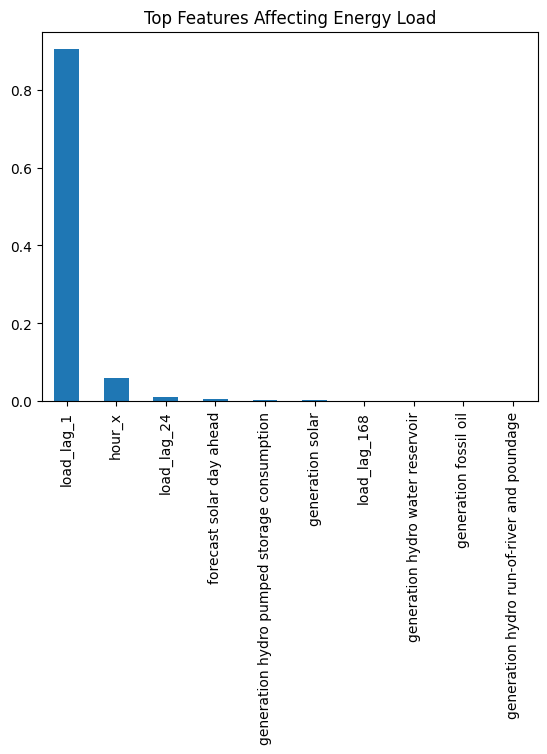

In [12]:
importance.head(10).plot(kind="bar")
plt.title("Top Features Affecting Energy Load")
plt.show()

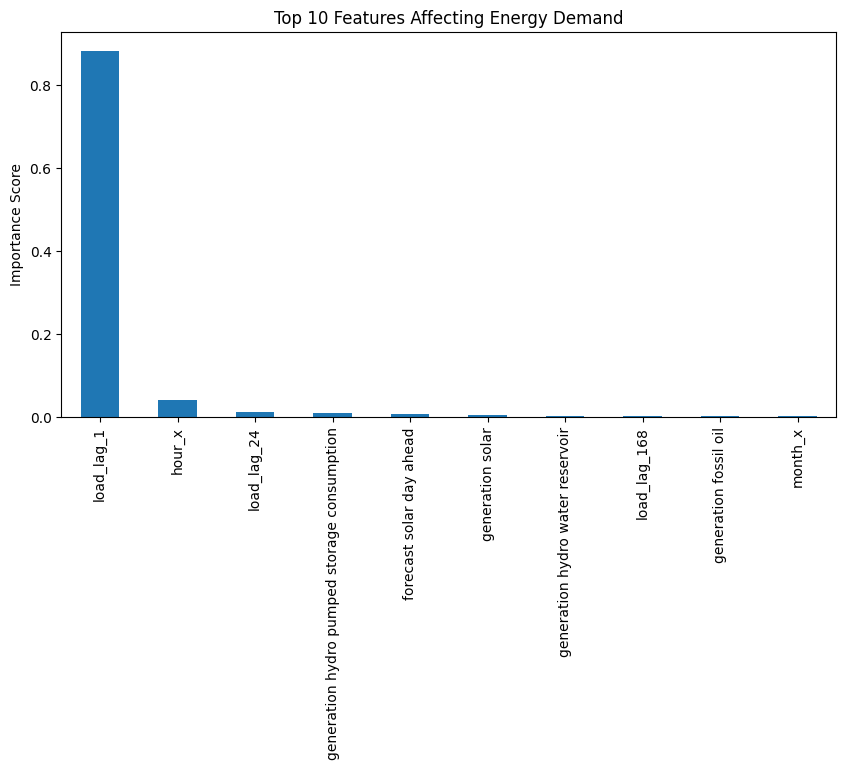

In [ ]:
# Feature Importance Plot (XGBoost)
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    xgb_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

importance.head(10).plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Features Affecting Energy Demand")
plt.ylabel("Importance Score")
plt.show()

In [15]:
import os
import joblib

os.makedirs("models", exist_ok=True)

joblib.dump(xgb_model, "models/xgboost_energy_model_v1.pkl")

['models/xgboost_energy_model_v1.pkl']